In [43]:
#EMA filter

import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

def EMAFilter(x, alpha, y_prev):
    return alpha * x + (1-alpha)*y_prev


def EMAFilterResponse(alpha):
    b = [alpha] #numerator
    a = [1, -1+alpha] #denominator
    return b,a

def BiquadFilterResponseNotch():
    b = (np.array([0.499411721096735, -0.993883735162081, 0.499280992451565]) * 2)
    a = (np.array([-0.5, 0.993883735162081, -0.498692713548301]) * -2)
    return b,a

# Low pass filter 5KHz -10dB
# a1 = -1.45421890
# a2 = 0.57402453
# b0 = 0.02995141
# b1 = 0.05990281
# b2 = 0.02995141
def BiquadFilterResponseLow():
    b = (np.array([0.02995141, 0.05990281, 0.02995141]))
    a = (np.array([1, -1.45421890, 0.57402453]))
    return b,a

#High pass filter 550Hz -10dB
# a1 = -1.83371141
# a2 = 0.84651057
# b0 = 0.92005550
# b1 = -1.84011099
# b2 = 0.92005550
def BiquadFilterResponseHigh():
    b = (np.array([0.92005550, -1.84011099, 0.92005550]))
    a = (np.array([1, -1.83371141, 0.84651057]))
    return b,a

def FindNearest(array, value):
    array = np.asarray(array)
    return (np.abs(array - value)).argmin()

In [31]:

fs = 60
f_c = 1000
w_c = 2 * np.pi * f_c
delta = 4 * (1 - np.cos(w_c) )**2 - 4 * (-2 - 2 * np.cos(w_c))
alpha_1 = ( -2 * (1 - np.cos(w_c)) - np.sqrt( delta ) ) / (2)
alpha_2 = ( -2 * (1 - np.cos(w_c)) + np.sqrt( delta ) ) / (2)

print("$a_1 = " + str(alpha_1))
print("$a_2 = " + str(alpha_2))

alpha = -alpha_2

$a_1 = -2.0
$a_2 = 2.0


In [58]:
fs = 48000
a = 0.01
alpha = a *fs

b1,a1 = BiquadFilterResponseHigh()
b2,a2 = BiquadFilterResponseLow() 

print("Hight pass filter {b1,a1} = " + str(b1/2) + " " + str(a1/-2))
print("Low pass filter {b2,a2} = " + str(b2/2) + " " + str(a2/-2))

a = np.convolve(a1,a2)
b = np.convolve(b1,b2) 

w, h = signal.freqz(b,a,fs=fs)


Hight pass filter {b1,a1} = [ 0.46002775 -0.92005549  0.46002775] [-0.5         0.91685571 -0.42325528]
Low pass filter {b2,a2} = [0.01497571 0.02995141 0.01497571] [-0.5         0.72710945 -0.28701226]
cutoff freq = 5062.5


In [ ]:
h = 20 * np.log10(abs(h))

idx = FindNearest(h, -10)
print("cutoff freq = " + str(w[idx]))

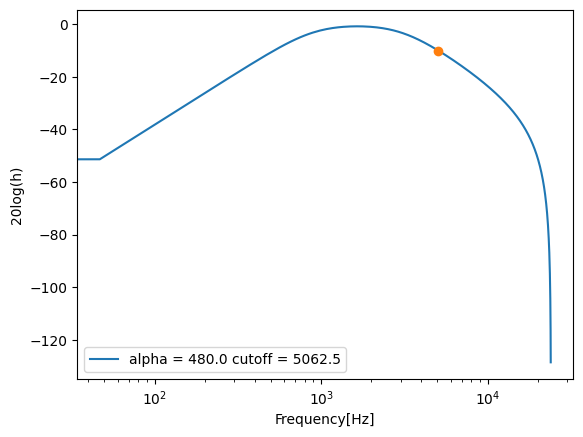

In [57]:
plt.semilogx(w, h, label="alpha = "+ str(alpha) +" cutoff = " + str(w[idx]))
plt.plot(w[idx], h[idx],'o')
plt.xlabel('Frequency[Hz]')
plt.ylabel('20log(h)')
plt.legend()